In [25]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf

import warnings 
warnings.filterwarnings('ignore')

In [2]:
print('hellow')

hellow


In [3]:
df  = pd.read_csv('Session 22 A.csv')
df.head()


,Date,Visitors,Promotion,Weekend,Holiday,Temperature,Average_Order_Value,Sales
0,1/1/2025,306,0,0,1,26.4,1110.29,401.39
1,1/2/2025,194,0,0,0,24.6,792.90,163.06
2,1/3/2025,227,0,0,0,24.4,966.08,257.94
3,1/4/2025,223,0,1,0,22.7,778.31,218.97
4,1/5/2025,314,0,1,0,23.1,960.03,280.84


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 365 non-null    object 
 1   Visitors             365 non-null    int64  
 2   Promotion            365 non-null    int64  
 3   Weekend              365 non-null    int64  
 4   Holiday              365 non-null    int64  
 5   Temperature          365 non-null    float64
 6   Average_Order_Value  365 non-null    float64
 7   Sales                365 non-null    float64
dtypes: float64(3), int64(4), object(1)
memory usage: 22.9+ KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 365 non-null    datetime64[ns]
 1   Visitors             365 non-null    int64         
 2   Promotion            365 non-null    int64         
 3   Weekend              365 non-null    int64         
 4   Holiday              365 non-null    int64         
 5   Temperature          365 non-null    float64       
 6   Average_Order_Value  365 non-null    float64       
 7   Sales                365 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(4)
memory usage: 22.9 KB


In [7]:
df.dtypes

Date                   datetime64[ns]
Visitors                        int64
Promotion                       int64
Weekend                         int64
Holiday                         int64
Temperature                   float64
Average_Order_Value           float64
Sales                         float64
dtype: object

In [8]:
df

,Date,Visitors,Promotion,Weekend,Holiday,Temperature,Average_Order_Value,Sales
0,2025-01-01,306,0,0,1,26.4,1110.29,401.39
1,2025-01-02,194,0,0,0,24.6,792.90,163.06
2,2025-01-03,227,0,0,0,24.4,966.08,257.94
3,2025-01-04,223,0,1,0,22.7,778.31,218.97
4,2025-01-05,314,0,1,0,23.1,960.03,280.84
...,...,...,...,...,...,...,...,...
360,2025-12-27,279,0,1,0,24.4,849.84,296.94
361,2025-12-28,236,0,1,0,24.6,804.24,248.21
362,2025-12-29,221,0,0,0,21.2,927.64,272.46
363,2025-12-30,206,0,0,0,25.0,888.17,216.08


In [9]:
df.isnull().sum()

Date                   0
Visitors               0
Promotion              0
Weekend                0
Holiday                0
Temperature            0
Average_Order_Value    0
Sales                  0
dtype: int64

In [10]:
df['Date'].dt.year



0      2025
1      2025
2      2025
3      2025
4      2025
       ... 
360    2025
361    2025
362    2025
363    2025
364    2025
Name: Date, Length: 365, dtype: int32

In [11]:
df['Date'].dt.month

0       1
1       1
2       1
3       1
4       1
       ..
360    12
361    12
362    12
363    12
364    12
Name: Date, Length: 365, dtype: int32

In [12]:

df['Date'].dt.day

0       1
1       2
2       3
3       4
4       5
       ..
360    27
361    28
362    29
363    30
364    31
Name: Date, Length: 365, dtype: int32

In [13]:

df['Date'].dt.hour

0      0
1      0
2      0
3      0
4      0
      ..
360    0
361    0
362    0
363    0
364    0
Name: Date, Length: 365, dtype: int32

In [15]:
from datetime import datetime, date, time, timedelta

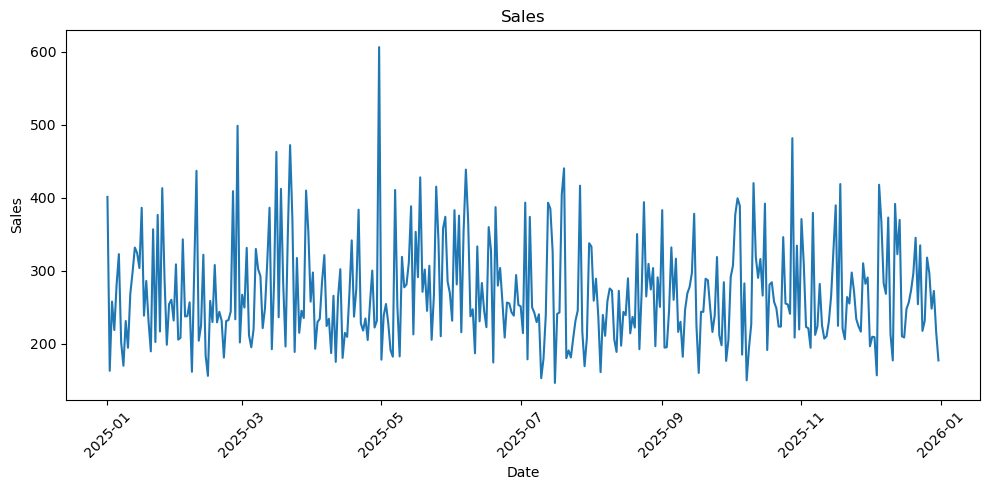

In [18]:
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Sales'])
plt.title('Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
df.columns

Index(['Date', 'Visitors', 'Promotion', 'Weekend', 'Holiday', 'Temperature',
       'Average_Order_Value', 'Sales'],
      dtype='object')

In [20]:
feature_cols = ['Visitors', 'Promotion', 'Weekend', 'Holiday', 'Temperature',
       'Average_Order_Value', 'Sales']

In [21]:
feature_cols

['Visitors',
 'Promotion',
 'Weekend',
 'Holiday',
 'Temperature',
 'Average_Order_Value',
 'Sales']

In [24]:
feature_Scaler = MinMaxScaler()
scaled_features = feature_Scaler.fit_transform(df[feature_cols])
scaled_features

array([[0.70212766, 0.        , 0.        , ..., 0.55555556, 0.71243877,
        0.55398153],
       [0.10638298, 0.        , 0.        , ..., 0.48412698, 0.27073592,
        0.03615426],
       [0.28191489, 0.        , 0.        , ..., 0.47619048, 0.51174571,
        0.2423031 ],
       ...,
       [0.25      , 0.        , 0.        , ..., 0.34920635, 0.45824983,
        0.27385117],
       [0.17021277, 0.        , 0.        , ..., 0.5       , 0.40332053,
        0.15135253],
       [0.2393617 , 0.        , 0.        , ..., 0.65873016, 0.31668893,
        0.06707224]], shape=(365, 7))

In [26]:
scaled_features.shape

(365, 7)

In [28]:
type(scaled_features)

numpy.ndarray

In [29]:
type(feature_cols)

list

In [33]:
target_scaler = MinMaxScaler()
scaled_target = target_scaler.fit_transform(df[['Sales']])
scaled_target

array([[0.55398153],
       [0.03615426],
       [0.2423031 ],
       [0.15763172],
       [0.29205866],
       [0.3836176 ],
       [0.12108637],
       [0.05114612],
       [0.18442151],
       [0.10466051],
       [0.26487778],
       [0.32936448],
       [0.40312873],
       [0.38707224],
       [0.34209669],
       [0.52156437],
       [0.20034764],
       [0.30368278],
       [0.18366105],
       [0.09401412],
       [0.45762086],
       [0.121912  ],
       [0.50031505],
       [0.15315589],
       [0.57998914],
       [0.31065725],
       [0.11365562],
       [0.23491581],
       [0.24758284],
       [0.18587724],
       [0.35313417],
       [0.12899511],
       [0.13418794],
       [0.42761543],
       [0.197849  ],
       [0.19915263],
       [0.24      ],
       [0.03317762],
       [0.33529603],
       [0.6315698 ],
       [0.12577947],
       [0.17101575],
       [0.38170559],
       [0.08212928],
       [0.02105378],
       [0.2442151 ],
       [0.18140141],
       [0.351

In [34]:
scaled_target.shape

(365, 1)

In [40]:
scaled_features = feature_Scaler.fit_transform(df[feature_cols])
len(scaled_features)


365

In [ ]:
def create_Sequence(features, target, time_shapes=7):
    x = []
    y = []
    for i in range(len(features) - time_shapes):
        x.append(features[i:i + time_shapes])
        y.append(target[i + time_shapes])
    return np.array(x), np.array(y)


In [45]:
x,y = create_Sequence(scaled_features, scaled_target, time_shapes=7)
print('x shape', x.shape)
print('y shape,', y.shape)

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
split_index = int(len(x) * 0.80)
x_train  = x[:split ]

In [ ]:
# run the next cell to create and summarize the model


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, activation='relu', input_shape=(x.shape[1], x.shape[2])),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()
